In [1]:
from prediction_codes import *
import os,sys
import glob
import matplotlib as mpl
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d

font = {'size'   : 25}
mpl.rc('font', **font) 

In [2]:
flux_factor_for_alert= 50 # Fixed for now
leave_number_indices=30

# Note fixing path for my directory, please change this based on your installation
wdir = "/Users/aadesai1/Desktop/In_use/ML_work/Fermi_amego_alert_project/Main/Model_predictions/cache_folder/"
os.chdir(wdir)

num_alerts_files = glob.glob(f'../../Fermi_sample/alerts_per_year_flux_factor_{flux_factor_for_alert}/num_alerts_per_year_file_*')
alerts_per_bin_files = glob.glob(f'../../Fermi_sample/alerts_per_year_flux_factor_{flux_factor_for_alert}/alerts_flux_data_per_year_file_*')

print("Current working directory: ",os.getcwd())

src_names=[]
for path_name in num_alerts_files:
    src_names.append(path_name[-21:][:-4])


id_val = "v3"

Current working directory:  /Users/aadesai1/Desktop/In_use/ML_work/Fermi_amego_alert_project/Main/Model_predictions/cache_folder


In [11]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



Data shape: (300, 2)
Running on /Users/aadesai1/Desktop/In_use/ML_work/Fermi_amego_alert_project/Main/Model_predictions/cache_folder//src_4FGL_J2207.5-5346flux_factor_50/seed_2/
Initializing AstroLightcurveDataset with seq_length 12 and forecast_horizon 30
Dataset creation complete!
Dataset size: 229, Train: 183, Val: 46
Epoch 10
  Train Loss: 2.47459
  Val Loss:   2.46235
Epoch 20
  Train Loss: 2.07103
  Val Loss:   2.68121

✓ Early stopping at epoch 23
  Best val loss: 2.45749 at epoch 8
Training done!

Validation prediction:
  Using sequence indices: 258 to 270
  Predicting indices: 270 to 300

Validation Metrics:
  Flux  MAPE:  19.00%
  Index MAPE:  30.22%
  Flux  RMSE:  1.797e-08
  Index RMSE:  2.991
[54714.5        54735.4531771  54756.40635421 54777.35953131
 54798.31270841 54819.26588551 54840.21906262 54861.17223972
 54882.12541682 54903.07859392 54924.03177103 54944.98494813
 54965.93812523 54986.89130233 55007.84447944 55028.79765654
 55049.75083364 55070.70401075 55091.6571

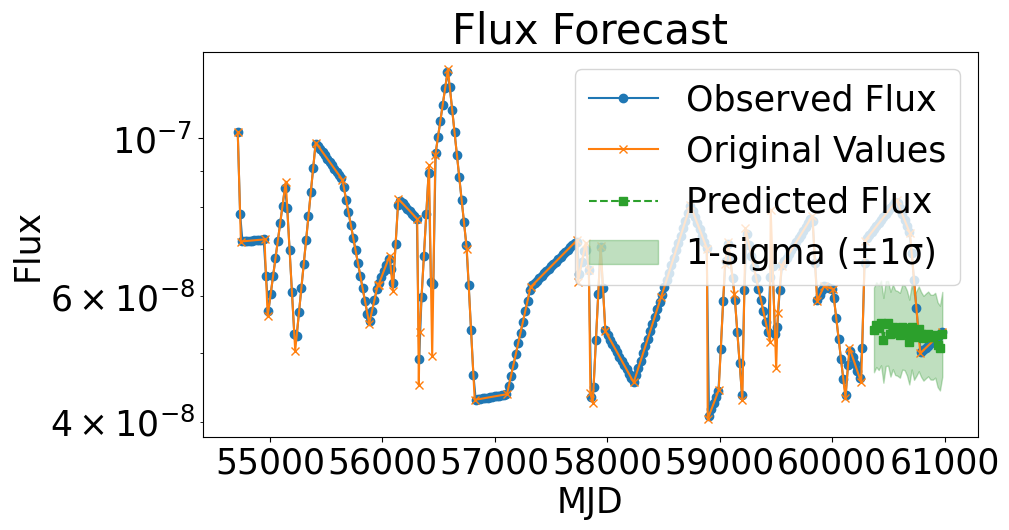

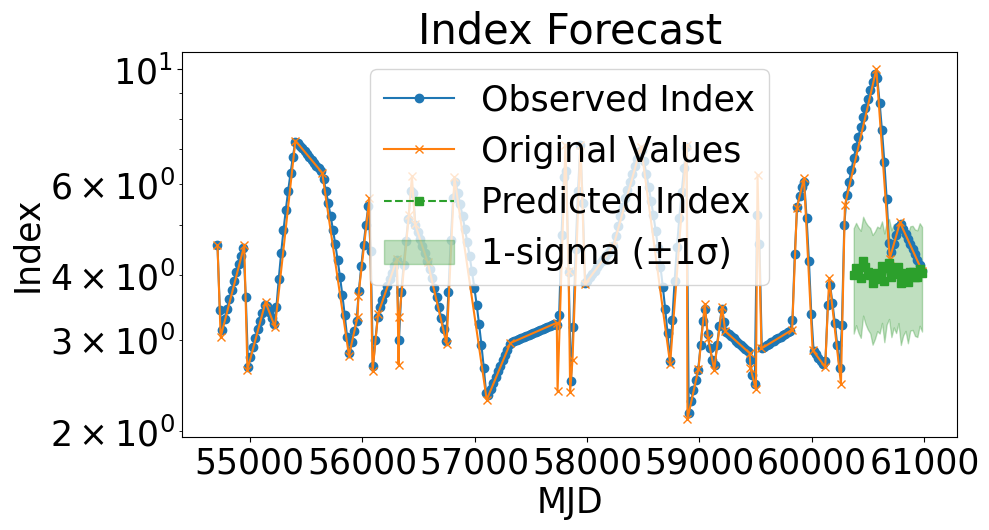

In [14]:
for src_index in range(len(src_names)): 
    os.chdir(wdir) 
    if src_index!=2: #Test one source
        continue
    src_dir = f'{wdir}/src_{src_names[src_index]}flux_factor_{flux_factor_for_alert}/'
    if os.path.isdir(src_dir)==False:
        os.mkdir(src_dir)

    
    seed = 2
    set_seed(seed)
    src_dir = f'{wdir}/src_{src_names[src_index]}flux_factor_{flux_factor_for_alert}/seed_{seed}/'
    if os.path.isdir(src_dir)==False:
        os.mkdir(src_dir)
    
    alerts_data = np.load(alerts_per_bin_files[src_index])
    all_times = alerts_data[0]  # MJD times
    all_flux = np.log10(alerts_data[1])   # Flux values
    all_index = alerts_data[2]  # Index values
        
    # Create DataFrame with flux and index
    df_orig = pd.DataFrame({
            '#MJD': all_times,
            'flux': all_flux,
            'index': all_index
        })
    
    

    # Resample
    num_points = 300
    mjd_resampled = np.linspace(all_times.min(), all_times.max(), num_points)

    flux_interp = interp1d(all_times, all_flux, kind='linear')
    index_interp = interp1d(all_times, all_index, kind='linear')

    flux_resampled = flux_interp(mjd_resampled)
    index_resampled = index_interp(mjd_resampled)  

    #SPLIT INTO TRAIN AND TEST!
    test_split_idx = num_points - leave_number_indices  
    test_mjd = mjd_resampled[:test_split_idx]  
    test_flux = flux_resampled[:test_split_idx]  
    test_index = index_resampled[:test_split_idx]  
    
    df = pd.DataFrame({
        '#MJD': mjd_resampled,
        'flux': flux_resampled,
        'index': index_resampled
    })

    flux = flux_interp(mjd_resampled).reshape(-1,1)
    index = index_interp(mjd_resampled).reshape(-1,1)

    data = np.concatenate([flux, index], axis=1)

    flux_scaler = StandardScaler()
    index_scaler = StandardScaler()

    flux_scaled = flux_scaler.fit_transform(flux)
    index_scaled = index_scaler.fit_transform(index)

    data_scaled = np.concatenate([flux_scaled, index_scaled], axis=1)


    print(f"Data shape: {data_scaled.shape}")
    data_scaled_train = data_scaled[:test_split_idx] 

    seq_len = 12 
    forecast_horizon = leave_number_indices

    os.chdir(src_dir) 
    print(f'Running on {src_dir}')
    
    dataset = AstroLightcurveDataset(
        data_scaled_train,
        seq_len=seq_len,
        forecast_horizon=forecast_horizon
    )
    print("Dataset creation complete!")

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset,
        [train_size, val_size]
    )
    print(f"Dataset size: {len(dataset)}, Train: {train_size}, Val: {val_size}")

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32)

    #device = "cuda" if torch.cuda.is_available() else "cpu" 
    device = "cpu"

    model = AstroForecastModel(
        input_dim=2,            # flux + index
        hidden_dim=32,
        forecast_horizon=forecast_horizon,
        num_heads=2
    )


    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=120,
        lr=3e-4,
        device=device,
        patience=15  # Early stopping
    )

    print("Training done!")

    # ===== VALIDATION: Predict last forecast_horizon points =====
    # Get the sequence BEFORE the last forecast_horizon points
    last_sequence = data_scaled[test_split_idx - seq_len:test_split_idx]
    
 
    print(f"\nValidation prediction:")
    print(f"  Using sequence indices: {test_split_idx - seq_len} to {test_split_idx}")
    print(f"  Predicting indices: {test_split_idx} to {test_split_idx + forecast_horizon}")
 
    last_sequence = data_scaled[-seq_len:]

    forecast_results = forecast(
        model,
        last_sequence,
        flux_scaler,index_scaler,
        flux_is_log=True,
        device=device
    )
    flux_pred = forecast_results['flux']
    flux_lower = forecast_results['flux_lower']
    flux_upper = forecast_results['flux_upper']
    index_pred = forecast_results['index']
    index_lower = forecast_results['index_lower']
    index_upper = forecast_results['index_upper']
    std = forecast_results['std']

    mjd = df['#MJD'].values
    future_mjd = mjd_resampled[test_split_idx:]

    # Validation targets from resampled data
    val_flux_observed = flux_resampled[test_split_idx:]  # Convert to linear for comparison
    val_index_observed = index_resampled[test_split_idx:]
    
    # Compute metrics
    mape_flux = np.mean(np.abs((flux_pred - 10**val_flux_observed) / (10**val_flux_observed + 1e-10))) * 100
    mape_index = np.mean(np.abs((index_pred - val_index_observed) / (val_index_observed + 1e-10))) * 100
    rmse_flux = np.sqrt(np.mean((flux_pred - 10**val_flux_observed)**2))
    rmse_index = np.sqrt(np.mean((index_pred - val_index_observed)**2))

    print(f"\nValidation Metrics:")
    print(f"  Flux  MAPE:  {mape_flux:.2f}%")
    print(f"  Index MAPE:  {mape_index:.2f}%")
    print(f"  Flux  RMSE:  {rmse_flux:.3e}")
    print(f"  Index RMSE:  {rmse_index:.3f}")

    plt.figure(figsize=(10,5))

    print(mjd,df["flux"].values)
    # OG DATA
    plt.plot(
        mjd,
        10**df["flux"].values,
        marker="o",
        label="Observed Flux"
    )
    
    # Training data
    plt.plot(
        df_orig['#MJD'].values,
        10**df_orig["flux"].values,
        marker="x",
        label="Original Values"
    )

    # Prediction
    plt.plot(
        future_mjd,
        flux_pred,
        marker="s",
        linestyle="--",
        label="Predicted Flux"
    )

    # 1-sigma uncertainty band (mean ± std)
    plt.fill_between(
        future_mjd,
        flux_lower,
        flux_upper,
        alpha=0.25,
        color='green',
        label='1-sigma (±1σ)'
    )


    plt.xlabel("MJD")
    plt.ylabel("Flux")
    plt.yscale("log")

    plt.legend()
    plt.title("Flux Forecast")

    plt.show()

    plt.figure(figsize=(10,5))

    
    # OG DATA
    plt.plot(
        mjd,
        df["index"].values,
        marker="o",
        label="Observed Index"
    )
    
    # Training data
    plt.plot(
        df_orig['#MJD'].values,
        df_orig["index"].values,
        marker="x",
        label="Original Values"
    )

    # Prediction
    plt.plot(
        future_mjd,
        index_pred,
        marker="s",
        linestyle="--",
        label="Predicted Index"
    )

    # 1-sigma uncertainty band (mean ± std)
    plt.fill_between(
        future_mjd,
        index_lower,
        index_upper,
        alpha=0.25,
        color='green',
        label='1-sigma (±1σ)'
    )

    plt.xlabel("MJD")
    plt.ylabel("Index")
    plt.yscale("log")

    plt.legend()
    plt.title("Index Forecast")

    plt.show()

    #torch.save({
    #"model_state_dict": model.state_dict(),
    #"scaler": scaler
    #}, "astro_forecast_model.pth")



    


